# 06 — Paper-style Reproduction (Early Prediction of Gallstone Disease)

This notebook aims to closely mirror the modelling pipeline described in the paper *"Early prediction of gallstone disease with a machine learning based model"*:

- 70/30 train–test split (stratified)
- ANOVA F-score feature ranking on the **train set only**
- Keep **top 32 features** (paper ends up with 32 after applying F≥0.70)
- Compare 9 ML models with **10-fold cross-validated grid search**
- Use ROC–AUC as the main CV selection metric, and report Accuracy, Precision, Recall, F1, ROC–AUC on the test set.

You can run this notebook end-to-end to get a leaderboard similar to the study (numbers may differ slightly due to randomness, implementation details, and potential data pre-processing differences).

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt

DATA_PATH = "../data/raw/dataset-uci.csv"
RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(319, 39)


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6


## 1. Target Encoding and 70/30 Split

In [5]:
# Check for missing values in the target column
TARGET = "Gallstone Status"
print(f"Target column '{TARGET}' info:")
print(f"Unique values: {df[TARGET].unique()}")
print(f"Value counts:\n{df[TARGET].value_counts(dropna=False)}")
print(f"Missing values: {df[TARGET].isna().sum()}")
print(f"Data type: {df[TARGET].dtype}")

# Check if there are any non-finite values
print(f"Non-finite values: {(~df[TARGET].isna() & ~np.isfinite(df[TARGET])).sum()}")

# Let's see first few rows of the target column
print(f"\nFirst 10 values of {TARGET}:")
print(df[TARGET].head(10).tolist())

Target column 'Gallstone Status' info:
Unique values: [0 1]
Value counts:
Gallstone Status
0    161
1    158
Name: count, dtype: int64
Missing values: 0
Data type: int64
Non-finite values: 0

First 10 values of Gallstone Status:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [7]:
TARGET = "Gallstone Status"
assert TARGET in df.columns, "Target column 'Gallstone Status' not found."

# The target is already encoded as 0/1, no need to map
y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])

print("Class distribution (full dataset):")
print(y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape

Class distribution (full dataset):
Gallstone Status
0    0.504702
1    0.495298
Name: proportion, dtype: float64


((223, 38), (96, 38))

## 2. ANOVA F-score Feature Selection (Train Only, Top 32 Features)
The paper removes features with F < 0.70 and ends up with 32 features. Here we directly select the top 32 scorers on **train only** using `SelectKBest(f_classif, k=32)`.

In [8]:
k_features = min(32, X_train.shape[1])

def make_pipeline(clf):
    """Common pipeline: StandardScaler -> SelectKBest(ANOVA) -> Classifier"""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("anova", SelectKBest(score_func=f_classif, k=k_features)),
        ("clf", clf),
    ])

# Quick check of ANOVA scores on train set (optional)
from sklearn.feature_selection import f_classif

F_vals, p_vals = f_classif(X_train, y_train)
anova_table = (
    pd.DataFrame({
        "feature": X_train.columns,
        "F": F_vals,
        "p": p_vals
    })
    .sort_values("F", ascending=False)
)
anova_table.head(15)

,feature,F,p
37,Vitamin D,30.759890,8.299782e-08
35,C-Reactive Protein (CRP),17.219178,4.753280e-05
18,Bone Mass (BM),13.359681,3.212441e-04
15,Lean Mass (LM) (%),8.799408,3.344496e-03
11,Extracellular Water (ECW),8.694854,3.534022e-03
14,Total Body Fat Ratio (TBFR) (%),8.311681,4.327990e-03
30,Aspartat Aminotransferaz (AST),7.908454,5.363136e-03
5,Hyperlipidemia,6.460762,1.171322e-02
28,High Density Lipoprotein (HDL),5.824143,1.662289e-02
10,Total Body Water (TBW),4.642691,3.226743e-02


## 3. Define Models and Hyperparameter Grids (as in the paper)
For each of the 9 models, we set up a GridSearchCV with 10-fold stratified CV and ROC–AUC scoring.

In [9]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

grids = {
    "KNN": {
        "estimator": make_pipeline(KNeighborsClassifier()),
        "param_grid": {
            "clf__n_neighbors": list(range(1, 31)),
            "clf__metric": ["manhattan", "euclidean", "chebyshev"],
        },
    },
    "MLP": {
        "estimator": make_pipeline(
            MLPClassifier(max_iter=2000, random_state=RANDOM_STATE, early_stopping=True)
        ),
        "param_grid": {
            "clf__hidden_layer_sizes": [(50,), (100,), (150,), (250,), (500,), (1000,)],
            "clf__activation": ["logistic", "tanh", "relu"],
        },
    },
    "SVM_RBF": {
        "estimator": make_pipeline(SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
        "param_grid": {
            "clf__C": [2**-5, 2**-1, 2**9],
            "clf__gamma": [2**-9, 2**-5, 2**-1, 2**3],
        },
    },
    "DecisionTree": {
        "estimator": make_pipeline(DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE)),
        "param_grid": {
            "clf__max_depth": [5, 10, 15, 20, 25],
            "clf__min_samples_leaf": [1, 2, 3],
            "clf__min_samples_split": [3, 4, 5, 6, 7],
        },
    },
    "RandomForest": {
        "estimator": make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE)),
        "param_grid": {
            "clf__n_estimators": [200, 400, 800],
            "clf__max_depth": [None, 5, 10, 15, 20, 25],
            "clf__min_samples_leaf": [1, 2, 3],
            "clf__min_samples_split": [3, 4, 5, 6, 7],
        },
    },
    "AdaBoost": {
        "estimator": make_pipeline(AdaBoostClassifier(random_state=RANDOM_STATE)),
        "param_grid": {
            "clf__learning_rate": [1.0, 0.15, 0.1, 0.05, 0.01, 0.005, 0.001],
            "clf__n_estimators": [50, 100, 200, 400],
        },
    },
    "GradientBoosting": {
        "estimator": make_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE)),
        "param_grid": {
            "clf__n_estimators": [100, 200, 400],
            "clf__learning_rate": [0.01, 0.05, 0.1, 0.15, 1.0],
            "clf__max_depth": [2, 3, 4],
        },
    },
    "NaiveBayes": {
        "estimator": make_pipeline(GaussianNB()),
        "param_grid": {
            # GaussianNB has var_smoothing; can be tuned if desired
        },
    },
    "LogisticRegression": {
        "estimator": make_pipeline(
            LogisticRegression(max_iter=1000, solver="lbfgs", random_state=RANDOM_STATE)
        ),
        "param_grid": {
            "clf__C": [0.01, 0.1, 1.0, 10.0],
            "clf__penalty": ["l2"],
        },
    },
}

## 4. 10-fold Grid Search with ROC–AUC

In [10]:
results = []
best_estimators = {}

for name, cfg in grids.items():
    print(f"\n=== {name} (10-fold GridSearchCV) ===")
    gs = GridSearchCV(
        estimator=cfg["estimator"],
        param_grid=cfg["param_grid"],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )
    gs.fit(X_train, y_train)
    best_estimators[name] = gs.best_estimator_
    print("Best params:", gs.best_params_)
    print("CV ROC-AUC:", gs.best_score_)
    results.append(
        {"model": name, "cv_roc_auc": gs.best_score_, "best_params": gs.best_params_}
    )

cv_leaderboard = (
    pd.DataFrame(results)
    .sort_values("cv_roc_auc", ascending=False)
    .reset_index(drop=True)
)
cv_leaderboard


=== KNN (10-fold GridSearchCV) ===
Best params: {'clf__metric': 'euclidean', 'clf__n_neighbors': 11}
CV ROC-AUC: 0.7219696969696969

=== MLP (10-fold GridSearchCV) ===
Best params: {'clf__metric': 'euclidean', 'clf__n_neighbors': 11}
CV ROC-AUC: 0.7219696969696969

=== MLP (10-fold GridSearchCV) ===
Best params: {'clf__activation': 'relu', 'clf__hidden_layer_sizes': (1000,)}
CV ROC-AUC: 0.7294765840220385

=== SVM_RBF (10-fold GridSearchCV) ===
Best params: {'clf__activation': 'relu', 'clf__hidden_layer_sizes': (1000,)}
CV ROC-AUC: 0.7294765840220385

=== SVM_RBF (10-fold GridSearchCV) ===
Best params: {'clf__C': 512, 'clf__gamma': 0.001953125}
CV ROC-AUC: 0.8308539944903581

=== DecisionTree (10-fold GridSearchCV) ===
Best params: {'clf__C': 512, 'clf__gamma': 0.001953125}
CV ROC-AUC: 0.8308539944903581

=== DecisionTree (10-fold GridSearchCV) ===
Best params: {'clf__max_depth': 15, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 7}
CV ROC-AUC: 0.709366391184573

=== RandomFore

,model,cv_roc_auc,best_params
0,GradientBoosting,0.837121,"{'clf__learning_rate': 1.0, 'clf__max_depth': ..."
1,RandomForest,0.834298,"{'clf__max_depth': None, 'clf__min_samples_lea..."
2,SVM_RBF,0.830854,"{'clf__C': 512, 'clf__gamma': 0.001953125}"
3,LogisticRegression,0.812879,"{'clf__C': 10.0, 'clf__penalty': 'l2'}"
4,AdaBoost,0.809022,"{'clf__learning_rate': 1.0, 'clf__n_estimators..."
5,MLP,0.729477,"{'clf__activation': 'relu', 'clf__hidden_layer..."
6,KNN,0.721970,"{'clf__metric': 'euclidean', 'clf__n_neighbors..."
7,DecisionTree,0.709366,"{'clf__max_depth': 15, 'clf__min_samples_leaf'..."
8,NaiveBayes,0.672727,{}


## 5. Evaluation on the Held-out Test Set

In [11]:
def evaluate(name, est, X_train, X_test, y_train, y_test):
    est.fit(X_train, y_train)
    y_hat = est.predict(X_test)
    if hasattr(est.named_steps["clf"], "predict_proba"):
        y_prob = est.predict_proba(X_test)[:, 1]
    else:
        if hasattr(est.named_steps["clf"], "decision_function"):
            scores = est.decision_function(X_test)
            y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
        else:
            y_prob = np.full_like(y_hat, fill_value=y_hat.mean(), dtype=float)

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_hat),
        "precision": precision_score(y_test, y_hat),
        "recall": recall_score(y_test, y_hat),
        "f1": f1_score(y_test, y_hat),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "report": classification_report(y_test, y_hat, digits=3),
        "y_hat": y_hat,
        "y_prob": y_prob,
    }

test_results = []
for name, est in best_estimators.items():
    test_results.append(evaluate(name, est, X_train, X_test, y_train, y_test))

test_table = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ("report", "y_hat", "y_prob")} for r in test_results]
).sort_values("roc_auc", ascending=False)
test_table

,model,accuracy,precision,recall,f1,roc_auc
6,GradientBoosting,0.833333,0.847826,0.812500,0.829787,0.905382
5,AdaBoost,0.854167,0.869565,0.833333,0.851064,0.900608
4,RandomForest,0.812500,0.800000,0.833333,0.816327,0.898872
2,SVM_RBF,0.864583,0.888889,0.833333,0.860215,0.890191
8,LogisticRegression,0.833333,0.833333,0.833333,0.833333,0.888455
1,MLP,0.750000,0.772727,0.708333,0.739130,0.848524
3,DecisionTree,0.770833,0.770833,0.770833,0.770833,0.783854
0,KNN,0.656250,0.692308,0.562500,0.620690,0.744358
7,NaiveBayes,0.552083,1.000000,0.104167,0.188679,0.701389


### Top Model Detailed Report + ROC Curve

Top model on test: GradientBoosting

Classification report (test):
              precision    recall  f1-score   support

           0      0.820     0.854     0.837        48
           1      0.848     0.812     0.830        48

    accuracy                          0.833        96
   macro avg      0.834     0.833     0.833        96
weighted avg      0.834     0.833     0.833        96



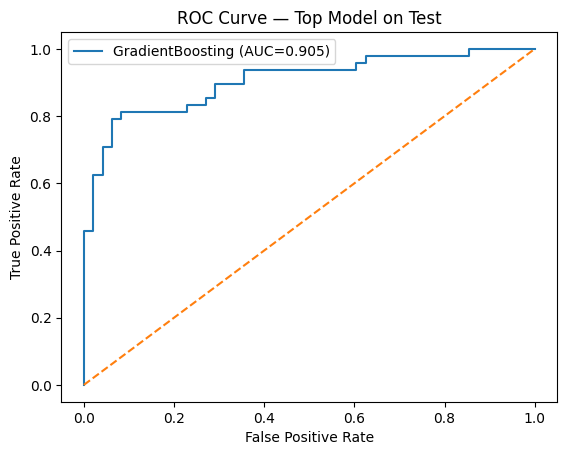

In [12]:
top_model_name = test_table.iloc[0]["model"]
print("Top model on test:", top_model_name)

top_result = next(r for r in test_results if r["model"] == top_model_name)
print("\nClassification report (test):")
print(top_result["report"])

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, top_result["y_prob"])
plt.figure()
plt.plot(fpr, tpr, label=f"{top_model_name} (AUC={top_result['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Top Model on Test")
plt.legend()
plt.show()

## 6. (Optional) Inspect the 32 Selected Features

In [16]:
any_pipe = best_estimators[top_model_name]
selector = any_pipe.named_steps["anova"]
support = selector.get_support()
selected_features = X_train.columns[support]
print("Selected features (k=32):")
list(selected_features)

# List top features by permutation importance
from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(
    any_pipe, X_test, y_test, n_repeats=30, random_state=RANDOM_STATE
)
perm_imp_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm_imp.importances_mean,
        "importance_std": perm_imp.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
perm_imp_df.head(32)

Selected features (k=32):


,feature,importance_mean,importance_std
0,C-Reactive Protein (CRP),0.087847,0.034199
1,Vitamin D,0.025694,0.020612
2,Triglyceride,0.020486,0.009503
3,Visceral Fat Area (VFA),0.014931,0.010306
4,Body Protein Content (Protein) (%),0.014931,0.019336
5,Total Fat Content (TFC),0.013542,0.006104
6,Extracellular Fluid/Total Body Water (ECF/TBW),0.012847,0.014404
7,Body Mass Index (BMI),0.010069,0.011246
8,Total Body Fat Ratio (TBFR) (%),0.008681,0.005435
9,Visceral Muscle Area (VMA) (Kg),0.007986,0.020427
